## <span style="color: #ffff00">Atelier Préparation de Données Textuelles</span>

### <span style="color: #ffff00">Contexte</span> 

Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 

Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client.

Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 

Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles. 

### <span style="color: #00ff0d">Partie 1 – Exploration du corpus</span>  

#### 1) Chargement des données CSV

In [2]:
import pandas as pd

df = pd.read_csv('../data/smart_reviews_raw.csv')
df

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr
...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr


#### 2) Nombre d'avis que contient le dataset

In [3]:
nombre_avis = len(df)

print(f"Le dataset contient {nombre_avis} avis clients.")

Le dataset contient 1200 avis clients.


In [4]:
# la forme complète du tableau
print(df.shape)

(1200, 8)


#### 3) Nombres de colonnes du dataset

In [6]:
# Le nombre de colonnes dans la liste des colonnes
nombre_colonnes = len(df.columns)

print(f"Le dataset possède {nombre_colonnes} colonnes.")
print("Liste des colonnes :", list(df.columns))

Le dataset possède 8 colonnes.
Liste des colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


#### 4) Le type de chaque colonne 

In [7]:
# le type de chaque colonne de manière synthétique
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

In [8]:
# On affiche un résumé technique complet du tableau
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id_avis    1200 non-null   str  
 1   date       1200 non-null   str  
 2   source     1200 non-null   str  
 3   produit    1200 non-null   str  
 4   texte      1195 non-null   str  
 5   sentiment  1200 non-null   str  
 6   note       1200 non-null   int64
 7   langue     1200 non-null   str  
dtypes: int64(1), str(7)
memory usage: 75.1 KB


#### 5) Detection des valeurs manquantes

In [9]:
# Le nombre de valeurs manquantes pour chaque colonne

valeurs_manquantes = df.isnull().sum()

print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)


Nombre de valeurs manquantes par colonne :
id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


#### 6) Identification quelques types de texte en affichant par exemple : texte normal ; texte vide... 

Pour isoler et afficher ces différents types de textes, on va utiliser des filtres Pandas basés sur des expressions régulières _Regex_ avec la méthode _.str.contains()_. Cela nous permet de chercher des motifs précis (comme http pour les URLs ou @ pour les mentions).

In [10]:
import re

print("EXEMPLES DE TEXTES RECHERCHÉS \n")

# Texte normal (simple, propre, sans artifice)
normal_sample = df[df['texte'] == "Excellent rapport qualité-prix."]['texte'].iloc[0]
print(f"1) Texte normal :\n-> \"{normal_sample}\"\n")

# Texte vide (ou contenant uniquement des espaces)
# On cherche les valeurs NaN détectées à la question 5

vide_sample = df[df['texte'].isnull() | (df['texte'].str.strip() == "")]['id_avis'].iloc[0]
print(f"2) Texte vide (Ligne manquante) :\n-> Identifié à l'avis : {vide_sample}\n")

# Texte contenant une URL (http ou https)

url_sample = df[df['texte'].str.contains(r'https?://\S+', na=False)]['texte'].iloc[0]
print(f"3) Texte avec URL :\n-> \"{url_sample}\"\n")

# Texte contenant une mention (@client)

mention_sample = df[df['texte'].str.contains(r'@\S+', na=False)]['texte'].iloc[0]
print(f"4) Texte avec mention :\n-> \"{mention_sample}\"\n")

# Texte contenant un hashtag (#avis)

hashtag_sample = df[df['texte'].str.contains(r'#\S+', na=False)]['texte'].iloc[0]
print(f"5) Texte avec hashtag :\n-> \"{hashtag_sample}\"\n")

# 6. Texte contenant des emojis (on cherche ici les emojis présents dans le corpus)

emoji_sample = df[df['texte'].str.contains(r'[\U00010000-\U0010ffff]', na=False)]['texte'].iloc[0]
print(f"6) Texte avec emojis :\n-> \"{emoji_sample}\"\n")

# Texte avec beaucoup de ponctuation répétée (ex: !!! ou !!!!!!!!!)

ponct_sample = df[df['texte'].str.contains(r'[!.?]{3,}', na=False)]['texte'].iloc[0]
print(f"7) Texte avec ponctuation répétée :\n-> \"{ponct_sample}\"\n")

# Texte en majuscules (complet)
# On filtre pour exclure les lignes vides, puis on vérifie si le texte est égal à sa version en majuscule

majuscule_df = df[df['texte'].notnull() & (df['texte'].str.strip() != "")]
maj_sample = majuscule_df[majuscule_df['texte'].str.isupper()]['texte'].iloc[0]
print(f"8) Texte entièrement en majuscules :\n-> \"{maj_sample}\"\n")

# Texte avec répétition de caractères (ex: trèèès)
rep_sample = df[df['texte'].str.contains(r'(.)\1{2,}', na=False)]['texte'].iloc[0]
print(f"9) Texte avec répétition de caractères :\n-> \"{rep_sample}\"\n")


EXEMPLES DE TEXTES RECHERCHÉS 

1) Texte normal :
-> "Excellent rapport qualité-prix."

2) Texte vide (Ligne manquante) :
-> Identifié à l'avis : AV0047

3) Texte avec URL :
-> "Produit parfait, rien à signaler. https://example.com/commande/17"

4) Texte avec mention :
-> "@client Livraison rapide et produit conforme à mes attentes."

5) Texte avec hashtag :
-> "Très satisfait de mon achat 👍 #avis"

6) Texte avec emojis :
-> "Très satisfait de mon achat 👍 #avis"

7) Texte avec ponctuation répétée :
-> "Produit excellent, je suis très satisfait. !!!"

8) Texte entièrement en majuscules :
-> "LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

9) Texte avec répétition de caractères :
-> "Produit excellent, je suis très satisfait. !!!"



C:\Users\cissc\AppData\Local\Temp\ipykernel_7804\738799241.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  rep_sample = df[df['texte'].str.contains(r'(.)\1{2,}', na=False)]['texte'].iloc[0]


#### 7) Mesure de la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : 
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

Pour mesurer la longueur des textes, on calcule généralement le nombre de caractères présents dans chaque phrase. En Pandas, on utilise la propriété _.str.len()_ pour réaliser ce calcul facilement.

Avant de faire le calcul, on remplace les valeurs manquantes (NaN) par une chaîne vide "" pour éviter que notre nouvelle colonne ne contienne des erreurs.

In [11]:
# On remplace les NaN par du texte vide pour éviter les erreurs de calcul
df['texte_rempli'] = df['texte'].fillna("")

# On crée la colonne 'longueur' qui compte le nombre de caractères
df['longueur'] = df['texte_rempli'].str.len()

# On supprime la colonne temporaire
df = df.drop(columns=['texte_rempli'])

# On utilise la méthode .describe() pour obtenir toutes les statistiques d'un coup
statistiques = df['longueur'].describe()
print(statistiques)

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64


Affichage lisible des longueurs

In [12]:
print(f"Longueur minimale : {df['longueur'].min()} caractères")
print(f"Longueur maximale : {df['longueur'].max()} caractères")
print(f"Longueur moyenne  : {df['longueur'].mean():.2f} caractères")
print(f"Médiane (Q2)      : {df['longueur'].median()} caractères")
print(f"Premier quartile (Q1) : {df['longueur'].quantile(0.25)} caractères")
print(f"Troisième quartile (Q3) : {df['longueur'].quantile(0.75)} caractères")

Longueur minimale : 0 caractères
Longueur maximale : 636 caractères
Longueur moyenne  : 48.96 caractères
Médiane (Q2)      : 48.0 caractères
Premier quartile (Q1) : 37.0 caractères
Troisième quartile (Q3) : 56.0 caractères


#### 8) Visualisation de la distribution de la longueur des avis 

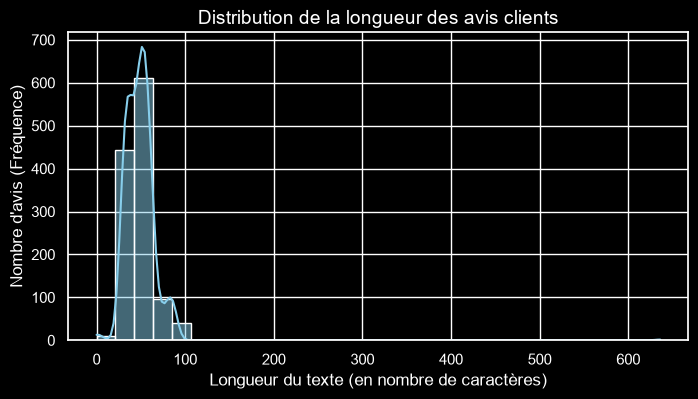

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# On configure le style graphique
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))

# On trace l'histogramme de la colonne longueur
sns.histplot(data=df, x='longueur', bins=30, kde=True, color='skyblue')

# On ajoute les titres et légendes
plt.title("Distribution de la longueur des avis clients", fontsize=14)
plt.xlabel("Longueur du texte (en nombre de caractères)", fontsize=12)
plt.ylabel("Nombre d'avis (Fréquence)", fontsize=12)

# On affiche le graphique
plt.show()